## Analisis Pola Penyewaan Sepeda Berdasarkan Waktu dan Kondisi Cuaca

### Anggota Kelompok 1 : 
1) **Ester** Yelisabeta - 5027261005
2) Muhammad **Naufal** Azmi - 5027261059
3) Muhammad **Ikhsanul** Amal - 5027161117

### Topik : Smart City - Bike Sharing

### Latar Belakang 
Penyewaan sepeda bersama atau yang biasa disebut bike sharing merupakan salah satu penerapan konsep smart city yang dapat membantu masyarakat dalam memenuhi kebutuhan transportasi sehari-hari. Dengan adanya layanan bike sharing, kami tertarik untuk memahami data mengenai penyewaan sepeda bersama dan mengetahui faktor-faktor yang berkaitan dengan jumlah penyewaan. Dataset yang kami analisis berjudul “Permintaan Penyewaan Sepeda per Jam & Cuaca”. Kami tertarik menganalisis dataset ini karena menunjukkan bagaimana jumlah penyewaan sepeda berubah berdasarkan waktu dan kondisi cuaca. Dari data tersebut, kami dapat melihat kapan sepeda paling banyak atau paling sedikit disewa serta bagaimana kondisi cuaca pada saat penyewaan terjadi.

### Pertanyaan Analisis 
1) Pada jam berapa jumlah penyewaan sepeda paling tinggi dan rendah?
2) Bagaimana perbedaan jumlah penyewaan sepeda berdasarkan kondisi cuaca?
3) Bagaimana rata-rata jumlah penyewaan sepeda berdasarkan waktu/ jam?

### Memuat Data

In [5]:
import pandas as pd

df = pd.read_csv("data/bike_sharing_hourly.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.head()

(17379, 19)


,record_id,datetime,date,year,month,hour,weekday,season,is_holiday,is_working_day,is_weekend,weather_condition,temperature_normalized,feels_like_temperature_normalized,humidity_percent,wind_speed_normalized,casual_rentals,registered_rentals,total_rentals
0,1,2011-01-01 00:00:00,2011-01-01,2011,1,0,Saturday,Winter,0,0,1,Clear or partly cloudy,0.24,0.2879,81.0,0.0,3,13,16
1,2,2011-01-01 01:00:00,2011-01-01,2011,1,1,Saturday,Winter,0,0,1,Clear or partly cloudy,0.22,0.2727,80.0,0.0,8,32,40
2,3,2011-01-01 02:00:00,2011-01-01,2011,1,2,Saturday,Winter,0,0,1,Clear or partly cloudy,0.22,0.2727,80.0,0.0,5,27,32
3,4,2011-01-01 03:00:00,2011-01-01,2011,1,3,Saturday,Winter,0,0,1,Clear or partly cloudy,0.24,0.2879,75.0,0.0,3,10,13
4,5,2011-01-01 04:00:00,2011-01-01,2011,1,4,Saturday,Winter,0,0,1,Clear or partly cloudy,0.24,0.2879,75.0,0.0,0,1,1


Setiap baris pada dataset menunjukkan data penyewaan sepeda dalam satu jam tertentu, seperti **waktu, kondisi cuaca dan jumlah sepeda yang disewa.**

### Deskripsi Data dan Kamus Data

Sumber Data: Diambil dari dataset publik Kaggle (Bike Sharing Demand: Hourly Rentals & Weather) https://www.kaggle.com/datasets/muhammadishahrukh/bike-sharing-demand-hourly-rentals-and-weather dengan lisensi CC BY-NC-SA 4.0 (Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International)  

Pengumpulan data: Dikumpulkan oleh Muhammad Ibrahim Shahrukh menggunakan data berdasarkan data asli penyewaan sepeda UCI (Capital Bikeshare system) https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset dan https://doi.org/10.24432/C5W894. Data mencakup dari tahun 2011 bulan Januari tanggal 1 hingga 2012 bulan Desember tanggal 31.  

Jumlah Baris dan Kolom: 17.379 baris dan 19 kolom  

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh | 
| :--- | :--- | :--- | :--- | :--- | :--- | 
| `record_id` | Indeks/ID unik setiap baris data | Kuantitatif diskrit | Nominal | – | 1 |
| `datetime` | Tanggal dan jam pencatatan | Kualitatif | Ordinal | YYYY-MM-DD HH:MM:SS | 2011-01-01 00:00:00 |
| `date` | Tanggal pencatatan | Kualitatif | Ordinal | YYYY-MM-DD | 2011-01-01 |
| `year` | Tahun pencatatan | Kuantitatif diskrit | Interval | Tahun | 2011 |
| `month` | Bulan pencatatan (1 s.d. 12) | Kualitatif | Ordinal | Bulan | 1 |
| `hour` | Jam pencatatan (0 s.d. 23) | Kualitatif | Ordinal | Jam | 0 |
| `weekday` | Nama hari dalam seminggu | Kualitatif | Nominal | – | Saturday |
| `season` | Musim saat pengukuran | Kualitatif | Nominal | – | Winter |
| `is_holiday` | Penanda apakah hari libur nasional (1=Ya, 0=Tidak) | Kualitatif | Nominal | – | 0 |
| `is_working_day` | Penanda apakah hari kerja (1=Ya, 0=Tidak) | Kualitatif | Nominal | – | 0 |
| `is_weekend` | Penanda apakah akhir pekan (1=Ya, 0=Tidak) | Kualitatif | Nominal | – | 1 |
| `weather_condition` | Kondisi cuaca saat pengukuran | Kualitatif | Ordinal | – | Clear or partly cloudy |
| `temperature_normalized` | Suhu lingkungan ternormalisasi | Kuantitatif kontinu | Rasio | Skala (0 s.d. 1) | 0.24 |
| `feels_like_temperature_normalized` | Suhu yang dirasakan (*feels like*) ternormalisasi | Kuantitatif kontinu | Rasio | Skala (0 s.d. 1) | 0.2879 |
| `humidity_percent` | Persentase kelembapan udara | Kuantitatif kontinu | Rasio | % | 81.0 |
| `wind_speed_normalized` | Kecepatan angin ternormalisasi | Kuantitatif kontinu | Rasio | Skala (0 s.d. 1) | 0.0 |
| `casual_rentals` | Jumlah penyewaan oleh pengguna non-berlangganan | Kuantitatif diskrit | Rasio | Unit sepeda | 3 |
| `registered_rentals` | Jumlah penyewaan oleh pengguna terdaftar/berlangganan | Kuantitatif diskrit | Rasio | Unit sepeda | 13 |
| `total_rentals` | Jumlah total penyewaan sepeda per jam | Kuantitatif diskrit | Rasio | Unit sepeda | 16 |

### Pemeriksaan Kualitas Data

In [35]:
import pandas as pd
df = pd.read_csv("data/bike_sharing_hourly.csv")
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   record_id                          17379 non-null  int64  
 1   datetime                           17379 non-null  str    
 2   date                               17379 non-null  str    
 3   year                               17379 non-null  int64  
 4   month                              17379 non-null  int64  
 5   hour                               17379 non-null  int64  
 6   weekday                            17379 non-null  str    
 7   season                             17379 non-null  str    
 8   is_holiday                         17379 non-null  int64  
 9   is_working_day                     17379 non-null  int64  
 10  is_weekend                         17379 non-null  int64  
 11  weather_condition                  17379 non-null  str    
 12  t

np.int64(0)

Dataset bike_sharing_hourly.csv ini sudah sangat bersih dan siap untuk tahap selanjutnya tanpa memerlukan pembresihan missing value maupun duplikasi.

### Statistik Deskriptif Variabel Numberik

Di tahapan ini, dilakukan analisis deskripstif pada 3 variabl numerik, yaitu `total_rentals`, `humidity_percent`, dan `temperature_normalized`. Mengapa pilih 3 variabel tersebut? Karena berkaitan dengan jumlah penyewaan sepeda dan kondisi cuaca sesuai dengan tujuan analisis.

In [25]:
kolom = df[[
    'total_rentals',
    'temperature_normalized',
    'humidity_percent',
]]

kolom.head()

,total_rentals,temperature_normalized,humidity_percent
0,16,0.24,81.0
1,40,0.22,80.0
2,32,0.22,80.0
3,13,0.24,75.0
4,1,0.24,75.0


#### A. Ukuran Pemusatan 
Digunakan untuk melihat nilai yang mewakili data, pada bagian ini digunakan *mean, median* dan *modus*.

In [26]:
print("Mean: ")
print(kolom.mean())

print("\nMedian: ")
print(kolom.median())

print("\nModus: ")
print(kolom.mode().iloc[0])

Mean: 
total_rentals             189.463088
temperature_normalized      0.496987
humidity_percent           62.722884
dtype: float64

Median: 
total_rentals             142.0
temperature_normalized      0.5
humidity_percent           63.0
dtype: float64

Modus: 
total_rentals              5.00
temperature_normalized     0.62
humidity_percent          88.00
Name: 0, dtype: float64


#### B. Ukuran Penyebaran
Digunakan untuk melihat seberapa jauh nilai-nilai dalam data tersebar. Ukuran yang digunakan adalah *nilai minimum, maksimum, jangkauan, varians* dan *simpangan baku.*

In [38]:
print("Minimum:")
print(kolom.min())

print("\nMaksimum:")
print(kolom.max())

print("\nJangkauan:")
print(kolom.max() - kolom.min())

print("\nVarians:")
print(kolom.var())

print("\nSimpangan Baku:")
print(kolom.std())

Minimum:
total_rentals             1.00
temperature_normalized    0.02
humidity_percent          0.00
dtype: float64

Maksimum:
total_rentals             977.0
temperature_normalized      1.0
humidity_percent          100.0
dtype: float64

Jangkauan:
total_rentals             976.00
temperature_normalized      0.98
humidity_percent          100.00
dtype: float64

Varians:
total_rentals             32901.461104
temperature_normalized        0.037078
humidity_percent            372.219209
dtype: float64

Simpangan Baku:
total_rentals             181.387599
temperature_normalized      0.192556
humidity_percent           19.292983
dtype: float64


#### C. Ukuran Letak
Digunakan untuk melihat posisi data dalam distribusi. Ukuran yang digunakan adalah *Q1, Q3* dan *IQR.*

In [39]:
q1 = kolom.quantile(0.25)
q3 = kolom.quantile(0.75)
iqr = q3 - q1

print("Q1:")
print(q1)

print("\nQ3:")
print(q3)

print("\nIQR:")
print(iqr)

Q1:
total_rentals             40.00
temperature_normalized     0.34
humidity_percent          48.00
Name: 0.25, dtype: float64

Q3:
total_rentals             281.00
temperature_normalized      0.66
humidity_percent           78.00
Name: 0.75, dtype: float64

IQR:
total_rentals             241.00
temperature_normalized      0.32
humidity_percent           30.00
dtype: float64


In [40]:
tabelRangkum = pd.DataFrame({
    'Mean': kolom.mean(),
    'Median' : kolom.median(),
    'Modus' : kolom.mode().iloc[0],
    'Minimum' : kolom.min(),
    'Maksimal' : kolom.max(),
    'Jangkauan' : kolom.max() - kolom.min(),
    'Varians' : kolom.var(),
    'Simpangan Baku' : kolom.std(),
    'Q1' : kolom.quantile(0.25),
    'Q2' : kolom.quantile(0.75),
    'IQR' : kolom.quantile(0.75) - kolom.quantile(0.25),
})

tabelRangkum

,Mean,Median,Modus,Minimum,Maksimal,Jangkauan,Varians,Simpangan Baku,Q1,Q2,IQR
total_rentals,189.463088,142.0,5.00,1.00,977.0,976.00,32901.461104,181.387599,40.00,281.00,241.00
temperature_normalized,0.496987,0.5,0.62,0.02,1.0,0.98,0.037078,0.192556,0.34,0.66,0.32
humidity_percent,62.722884,63.0,88.00,0.00,100.0,100.00,372.219209,19.292983,48.00,78.00,30.00


#### Interpretasi 

Berdasarkan hasil analisis, `total_rentals` memiliki rata-rata **189,46 sepeda per jam** dan median **142 sepeda per jam**. Perbedaan yang cukup besar antara rata-rata dan median menunjukkan bahwa distribusi data **cenderung miring ke kanan**, karena terdapat beberapa nilai penyewaan yang sangat tinggi. Sementara itu, `temperature_normalized` memiliki rata-rata dan median yang sama, yaitu sekitar **0,50**, sehingga sebarannya **cenderung lebih seimbang**. Pada `humidity_percent`, rata-rata sebesar **62,72%** dan median **63%** juga menunjukkan bahwa **sebaran datanya relatif seimbang.**

#### Perhitungan Variabel Manual

In [6]:
data_10 = df['total_rentals'].head(10)
data_10

0    16
1    40
2    32
3    13
4     1
5     1
6     2
7     3
8     8
9    14
Name: total_rentals, dtype: int64

In [8]:
n = len(data_10)
mean_10 = data_10.mean()
varManual = ((data_10 - mean_10) ** 2). sum() / (n-1)
varPandas = data_10.var()

print("Jumlah data:", n)
print("Rata-rata:", mean_10)
print("Varians manual:", varManual)
print("Varians Pandas:", varPandas)

Jumlah data: 10
Rata-rata: 13.0
Varians manual: 181.55555555555554
Varians Pandas: 181.55555555555554


Varian manual dan varian pandas setelah dihitung, menghasilkan nilai yang sama yaitu 181.56. Hal ini berarti perhitungan manual sudah sesuai dengan perhitungan pandas.

### Ringkasan Variabel Kategorik
Pada bagian ini, kami memanggil dataset penyewaan sepeda dan memilih kolom kategorik weather_condition (Kondisi Cuaca) untuk dihitung frekuensi kemunculannya beserta nilai persentasenya.

In [1]:
import pandas as pd

df = pd.read_csv("data/bike_sharing_hourly.csv")

print("Tabel Frekuensi Cuaca:")
print(df["weather_condition"].value_counts())

print("\nPersentasenya dalam (%):")
print(df["weather_condition"].value_counts(normalize=True) * 100)

Tabel Frekuensi Cuaca:
weather_condition
Clear or partly cloudy    11413
Mist or cloudy             4544
Light rain or snow         1419
Heavy rain or snow            3
Name: count, dtype: int64

Persentasenya dalam (%):
weather_condition
Clear or partly cloudy    65.671212
Mist or cloudy            26.146499
Light rain or snow         8.165027
Heavy rain or snow         0.017262
Name: proportion, dtype: float64


Berdasarkan tabel frekuensi di atas, kategori cuaca yang paling sering muncul (modus) adalah Clear or partly cloudy dengan total 11.413 atau sekitar 65,6% dari keseluruhan data.

### Visualisasi Data

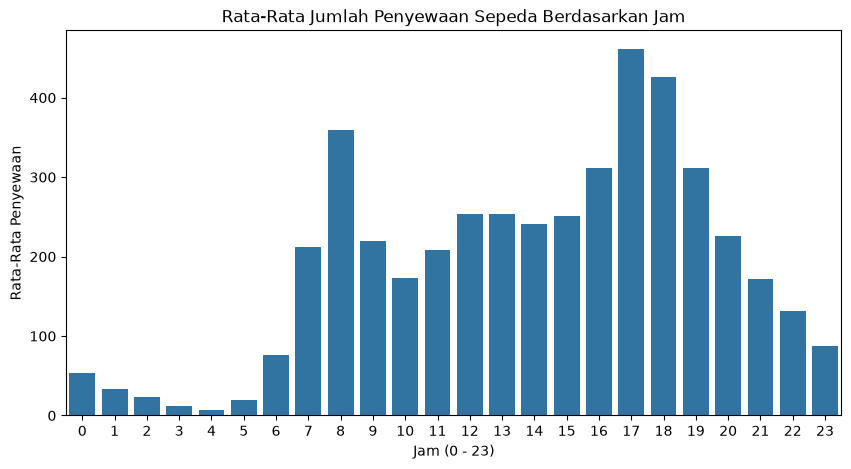

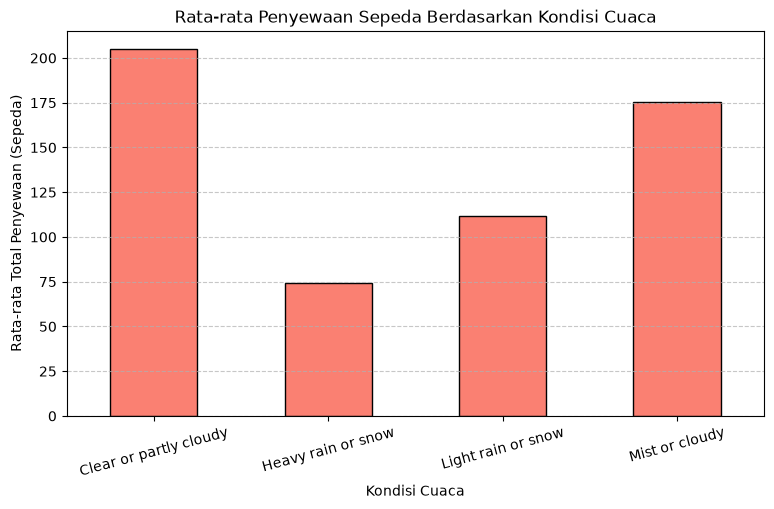

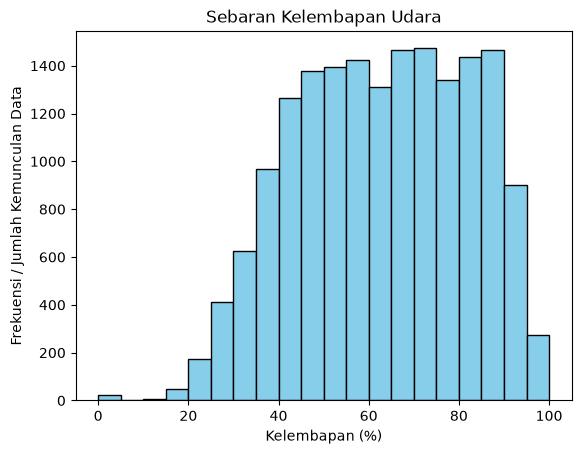

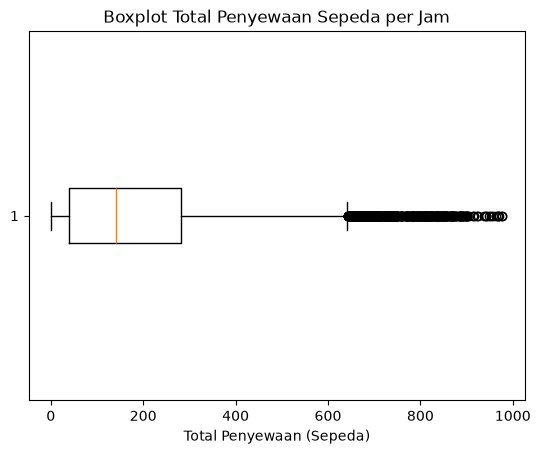

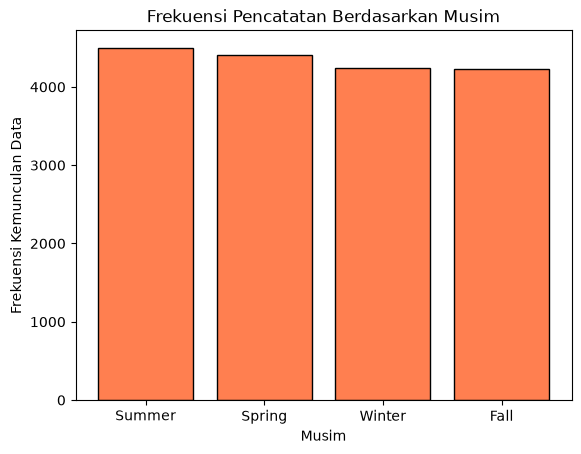

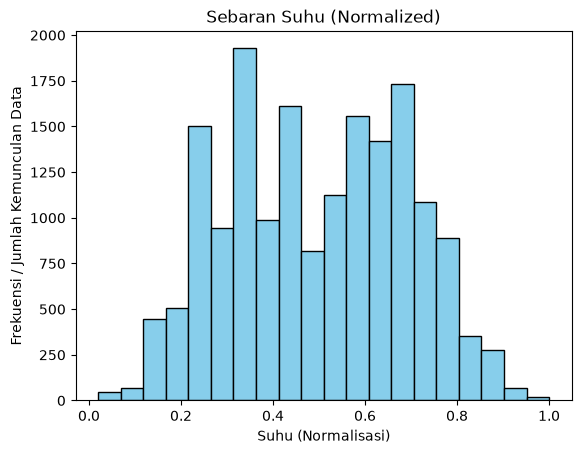

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("data/bike_sharing_hourly.csv")

# A. Diagram batang jumlah penyewaan sepeda
plt.figure(figsize=(10, 5))
sns.barplot(x="hour", y="total_rentals", data=df, estimator="mean", errorbar=None)
plt.title("Rata-Rata Jumlah Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Jam (0 - 23)")
plt.ylabel("Rata-Rata Penyewaan")
plt.show()

# B. Diagram Batang Rata-Rata Penyewaan Sepeda Berdasarkan Cuaca
plt.figure(figsize=(9, 5))
rata_rata_cuaca = df.groupby('weather_condition')['total_rentals'].mean()
rata_rata_cuaca.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Total Penyewaan (Sepeda)")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# C. Histogram Data Kelembapan Udara
plt.hist(df["humidity_percent"], bins=20, color='skyblue', edgecolor='black')
plt.title("Sebaran Kelembapan Udara")
plt.xlabel("Kelembapan (%)")
plt.ylabel("Frekuensi / Jumlah Kemunculan Data")
plt.show()

# D. Boxplot
plt.boxplot(df["total_rentals"], orientation='horizontal')
plt.title("Boxplot Total Penyewaan Sepeda per Jam")
plt.xlabel("Total Penyewaan (Sepeda)")
plt.show()

# E. Diagram Batang 
hitung_musim = df["season"].value_counts()
plt.bar(hitung_musim.index, hitung_musim.values, color='coral', edgecolor='black')
plt.title("Frekuensi Pencatatan Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Frekuensi Kemunculan Data")
plt.show()

# F. Histogram Temperature
plt.hist(df["temperature_normalized"], bins=20, color='skyblue', edgecolor='black')
plt.title("Sebaran Suhu (Normalized)")
plt.xlabel("Suhu (Normalisasi)")
plt.ylabel("Frekuensi / Jumlah Kemunculan Data")
plt.show()

### Interpretasi Data

Pada histogram pertama yaitu Penyewaan Sepeda per jam, Grafik ini menunjukkan pola mobilitas harian dengan dua puncak utama atau bimodal. Lonjakan pertama terjadi pada pukul 08:00 pagi yang menandakan jam berangkat kerja atau beraktivitas. Lonjakan kedua dan yang tertinggi terjadi pada pukul 17:00 dengan rata-rata mendekati 460 sepeda, yang mencerminkan jam pulang kerja. Sebaliknya, jumlah penyewaan paling sedikit terjadi pada dini hari, khususnya pukul 03:00 hingga 05:00 pagi, di mana aktivitas hampir tidak ada.

Jumlah penyewaan sepeda sangat dipengaruhi oleh kondisi cuaca. Berdasarkan hasil analisis, tingkat penyewaan tertinggi terjadi pada saat cuaca Clear or partly cloudy. Sebaliknya, semakin buruk kondisi cuaca, jumlah penyewaan menurun secara drastis

Pada Sebaran Kelembapan Udara, sebagian besar tingkat kelembapan udara di kota tersebut sering berada pada rentang menengah ke atas, yaitu antara 40% hingga 90%, dengan frekuensi kemunculan data tertinggi mencapai di atas 1.400 kali pada kisaran kelembapan 65%–85%.

Berdasarkan box plot tersebut, garis tengah oranye menunjukkan nilai median penyewaan berada di angka 142 sepeda per jam. Sebagian besar data normal (50% data tengah) berkisar antara kuartil pertama hingga kuartil ketiga. Deretan titik hitam di sisi kanan (kisaran 650 hingga mendekati 1.000 sepeda) merupakan data pencilan/outliers yang menunjukkan adanya lonjakan permintaan sangat ekstrem pada jam-jam tertentu.

Pada diagram batang musim, terlihat bahwa musim panas menjadi musim dengan jumlah frekuensi terbanyak dibanding musim lainnya.

### Visualisasi Data (Nilai Tambahan)

Median Penyewaan Sepeda Berdasarkan Hari Kerja (0 = Bukan Hari Kerja, 1 = Hari Kerja):
is_working_day
0    119.0
1    151.0
Name: total_rentals, dtype: float64


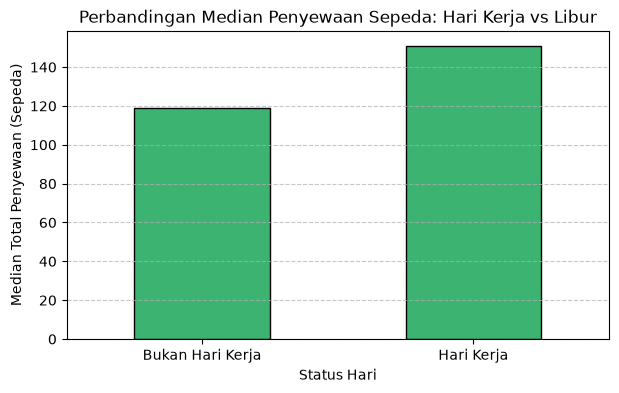

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/bike_sharing_hourly.csv")

median_kerja = df.groupby("is_working_day")["total_rentals"].median()
print("Median Penyewaan Sepeda Berdasarkan Hari Kerja (0 = Bukan Hari Kerja, 1 = Hari Kerja):")
print(median_kerja)


plt.figure(figsize=(7, 4))
median_kerja.index = ['Bukan Hari Kerja', 'Hari Kerja']
median_kerja.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title("Perbandingan Median Penyewaan Sepeda: Hari Kerja vs Libur")
plt.xlabel("Status Hari")
plt.ylabel("Median Total Penyewaan (Sepeda)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Berdasarkan grafik perbandingan tersebut, terlihat adanya perbedaan tingkat penggunaan layanan sepeda antara hari kerja dan hari libur. Median total penyewaan sepeda pada hari kerja tercatat lebih tinggi, yakni mencapai sekitar 150 sepeda, dibandingkan pada saat bukan hari kerja atau libur yang berada di kisaran 120 sepeda. Angka ini menunjukkan bahwa layanan bike sharing lebih banyak dimanfaatkan oleh masyarakat untuk mendukung kebutuhan mobilitas harian yang bersifat rutin dan terstruktur.

Aktivitas penyewaan tetap berjalan pada hari libur atau akhir pekan dengan tingkat permintaan yang sedikit lebih rendah, yang mengindikasikan bahwa penggunaan sepeda di luar hari kerja cenderung lebih bervariasi dan mungkin lebih didominasi oleh tujuan bersantai.

## Kesimpulan

Berdasarkan hasil analisis data penyewaan sepeda, diperoleh beberapa kesimpulan sebagai berikut:

1. **Pada jam berapa jumlah penyewaan sepeda paling tinggi dan rendah?**  
   Jumlah penyewaan sepeda paling tinggi terjadi pada pukul **17.00**, dengan rata-rata mendekati **460 sepeda per jam**. Sementara itu, jumlah penyewaan paling rendah terjadi pada dini hari, khususnya pada pukul **03.00–05.00**, ketika aktivitas penyewaan hampir tidak ada.

2. **Bagaimana perbedaan jumlah penyewaan sepeda berdasarkan kondisi cuaca?**  
   Penyewaan sepeda tertinggi terjadi pada kondisi cuaca **Clear or partly cloudy**. Secara umum, semakin buruk kondisi cuaca, jumlah penyewaan sepeda cenderung menurun secara drastis.

3. **Bagaimana rata-rata jumlah penyewaan sepeda berdasarkan waktu/jam?**  
   Rata-rata penyewaan sepeda terdapat dua puncak utama. Puncak pertama terjadi sekitar pukul **08.00**, sedangkan puncak tertinggi terjadi pada pukul **17.00** dengan rata-rata mendekati **460 sepeda per jam**. Penyewaan paling rendah terjadi pada dini hari sekitar pukul **03.00–05.00**.

**Dan ini adalah 3-5 temuan menarik yang kami temukan :**
1. Dataset hanya mencakup periode **Januari 2011 sampai Desember 2012**, sehingga data yang tersedia terbatas pada periode tersebut.
2. Dataset memiliki **jumlah data yang sangat sedikit pada beberapa kategori kondisi cuaca**. Salah satunya adalah kategori **Heavy rain or snow** yang hanya memiliki **3 data atau sekitar 0,017%** dari keseluruhan data. Hal ini membuat perbandingan pada kategori tersebut kurang kuat.hati-hati.

**Pertanyaan Lanjutan**
1. Apakah terdapat perbedaan jumlah penyewaan sepeda berdasarkan **musim**?
2. Bagaimana hubungan **suhu dan kelembapan** dengan jumlah penyewaan sepeda?
3. Apakah jumlah penyewaan berbeda secara jelas antara **hari kerja dan bukan hari kerja**?

## Referensi dan Catatan Penggunaan AI

### Referensi Belajar

- [GeeksforGeeks – How to Calculate Summary Statistics in Pandas](https://www.geeksforgeeks.org/pandas/how-to-calculate-summary-statistics-in-pandas/)
  (Cara menghitung statistik deskriptif atau ringkasan data menggunakan Pandas)
- [NIST/SEMATECH – Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/section3/eda356.htm) (Memahami analisis data eksploratif serta konsep dan rumus statistik, termasuk rumus **varians dan simpangan baku**)
- [Matplotlib](https://matplotlib.org/) (Cara menyajikan data dalam bentuk visual atau grafik)
- [W3Schools – Pandas CSV](https://www.w3schools.com/python/pandas/pandas_csv.asp) (Panduan menggunakan Pandas untuk membaca dan mengolah file CSV)


| Alat | Dipakai untuk | Yang kami pelajari |
| :--- | :--- | :--- |
| Gemini AI | Meminta Penjelasan Mengapa terdapat Deprecation Warning pada Data Boxplot | Peringatan bahwa cara penulisan sudah dianggap usang (deprecated) dan akan dihapus pada versi matplotlib terbaru, namun kode masih bisa dijalankan|
| Gemini AI | Menganalisis dataset bike_sharing_hourly.csv, mengatasi error Jupyter Notebook, dan mengecek kualitas data | Perbedaan data diskrit vs. kontinu, penanganan NameError & sintaks Python (duplicated()), serta analisis anomali/outlier |
| Gemini AI | Membandingkan dua dataset Kaggle bike sharing (London vs. Washington D.C.) | Perbedaan lokasi, variabel cuaca/kalender, dan pemisahan tipe pengguna (casual vs. registered) |
| Gemini AI | Memahami lisensi TfL, identifikasi pembuat dataset Kaggle, serta klasifikasi jenis data (day & year) | Ketentuan lisensi TfL (atribusi, limit API), cara mengecek pembuat dataset, serta konsep variabel Nominal/Ordinal (Hari) dan Interval (Tahun) |
| Gemini AI | Panduan penggunaan sel Markdown di Jupyter Notebook untuk penyusunan laporan proyek/tugas EDA | Fungsi sel Markdown vs. Code, shortcut ubah sel (Esc+M & Esc+Y), cara ganti baris (<br>, spasi 2x), dan pembuatan Kamus Data 6 kolom |
| Gemini AI | Troubleshooting error pembacaan file/path di Pandas serta penjelasan fungsi raw string dan tipe sel Raw | Solusi FileNotFoundError & SyntaxError (unicode escape), cara menangani backslash di Windows (path relatif, raw string r"", /), serta fungsi sel Raw di Jupyter |
| ChatGPT | Mempelajari fungsi `df.describe()` pada Pandas | Penjelasan statistik deskriptif yang dihasilkan, seperti count, mean, standar deviasi, minimum, kuartil, dan maksimum |
| ChatGPT | Mempelajari penggunaan Git dan GitHub dalam kolaborasi proyek | Cara melakukan `git pull` untuk mengambil perubahan terbaru dari repository GitHub dan `git push` untuk mengunggah perubahan dari komputer ke repository GitHub |
| ChatGPT | Mempelajari konsep statistik deskriptif | Penjelasan mengenai mean, median, modus, minimum, maksimum, jangkauan, varians, simpangan baku, Q1, Q3, dan IQR |